In [1]:
%matplotlib widget
import ipywidgets as widgets
# from IPython.display import clear_output
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd
# import numpy as np
from tqdm.autonotebook import tqdm
from scipy.ndimage import gaussian_filter1d
# import h5py
# import copy
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

# import shlex
import torch

from diffSPH.sampling import sampleRegularParticles, sampleOptimal
from diffSPH.operations import sph_operation, mod
from diffSPH.sampling import buildDomainDescription, sampleRegularParticles
from diffSPH.modules.eos import idealGasEOS
from diffSPH.schema import getSimulationScheme
from diffSPH.reference.sod import buildSod_reference, sodInitialState, generateSod1D
from diffSPH.modules.adaptiveSmoothingASPH import n_h_to_nH
from diffSPH.reference.sod import plotSod
from diffSPH.operations import GradientMode, LaplacianMode, SupportScheme
from diffSPH.enums import *
from diffSPH.schemes.states.common import BasicState
from diffSPH.neighborhood import SupportScheme, evaluateNeighborhood
from diffSPH.neighborhood import PointCloud, DomainDescription, buildNeighborhood, filterNeighborhood, coo_to_csrsc, coo_to_csr, filterNeighborhoodByKind
from diffSPH.modules.density import computeDensity

from diffSPH.sdf import operatorDict, getSDF
from diffSPH.sphOperations.shared import scatter_sum
from matplotlib.colors import LogNorm

from waveEqn import WaveEquationState, waveEquation2
from typing import Union, Tuple
from diffSPH.neighborhood import SparseNeighborhood, PrecomputedNeighborhood
from diffSPH.operations import GradientMode, LaplacianMode
from diffSPH.kernels import SPHKernel
from diffSPH.enums import *
from diffSPH.operations import SPHOperation, Operation
from diffSPH.schemes.states.common import BasicState
from diffSPH.neighborhood import SupportScheme, evaluateNeighborhood
from diffSPH.neighborhood import PointCloud, DomainDescription, buildNeighborhood, filterNeighborhood, coo_to_csrsc, coo_to_csr, filterNeighborhoodByKind
from diffSPH.operations import ParticleSetWithQuantity, sph_op
from diffSPH.kernels import getSPHKernelv2
from diffSPH.plotting import visualizeParticles, updatePlot, plotDistribution
from diffSPH.operations import SPHOperation, Operation
from diffSPH.util import getPeriodicPositions
from diffSPH.integrationSchemes.util import integrateQ
from diffSPH.integration import getIntegrator
import copy
from waveEqn import WaveSystem, waveSystemFunction

In [2]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = torch.float32
L = 2
dim = 2
nx = 128

kernel = KernelType.Wendland4
targetNeighbors = n_h_to_nH(4, dim)

domain = buildDomainDescription(L, dim, True, device, dtype)

particles = sampleOptimal(nx, domain, targetNeighbors, kernel, 0., 0, shiftScheme = 'delta')

config = {
    'domain': domain,
    'kernel': kernel,
    'targetNeighbors': targetNeighbors,
    'neighborhood':{
        'verletScale': 1.0
    }
}

config['gradientMode'] = GradientMode.Difference
config['laplacianMode'] = LaplacianMode.Brookshaw
config['supportScheme'] = SupportScheme.Gather
config['integrationScheme'] = IntegrationSchemeType.rungeKutta4

0it [00:00, ?it/s]

0it [00:00, ?it/s]

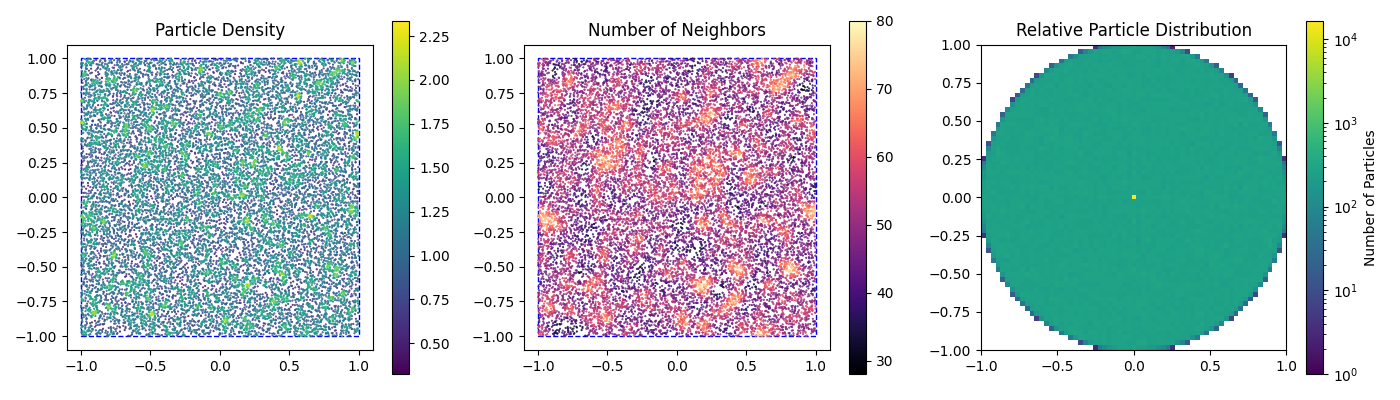

In [76]:
from util import visualize, sampleParticles
particles, numNeighbors, counter = sampleParticles(nx, scheme='random')

visualize(particles, numNeighbors, counter);

In [77]:
particleState = BasicState(particles.positions, particles.supports, particles.masses, particles.densities, torch.zeros_like(particles.positions), torch.zeros(particles.positions.shape[0], device = device, dtype = torch.int64), torch.zeros(particles.positions.shape[0], device = device, dtype = torch.int64), torch.arange(particles.positions.shape[0], device = device), particles.positions.shape[0])
neighborhood, neighbors = evaluateNeighborhood(particleState, config['domain'], kernel, verletScale = config['neighborhood']['verletScale'], mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)
particleState.numNeighbors = coo_to_csr(filterNeighborhoodByKind(particleState, neighbors.neighbors, which = 'noghost')).rowEntries
particleState.densities = computeDensity(particleState, kernel, neighbors.get('noghost'), SupportScheme.Gather, config)

In [78]:
# fig, axis = plt.subplots(1,2 , figsize=(10,4), squeeze=False)
# visualizeParticles(fig, axis[0,0], particleState, config['domain'], particleState.numNeighbors,
#     kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'magma', markerSize = 0.25, gridVisualization = False, title = 'Number of Neighbors')
# plotDistribution(fig, axis[0,1], particleState, neighbors.get('noghost'), 63)
# fig.tight_layout()

In [79]:
def sampleDamping(particleState, config):
    l = 0.8
    sphere_b = lambda points: getSDF('box')['function'](points, torch.tensor([l ,l]))
    sdf = operatorDict['invert'](sphere_b)

    dampGrid = sdf(getPeriodicPositions(particleState.positions, config['domain']).cpu()).to('cuda')
    dampGrid[dampGrid > 0] = 1
    dampGrid[dampGrid < 0] = torch.exp(- (dampGrid[dampGrid < 0] / (1-l))**2 / 4)

    dampGrid[:] = 1
    return dampGrid

In [80]:
from diffSPH.noise import generateOctaveNoise
from scipy.interpolate import RegularGridInterpolator
import numpy as np

def sampleVoronoi(positions, nGrid, octaves = 2, baseFrequency = 1, kind = 'perlin', tileable=True, seed = 12365, vmin = 0.0, vmax = 1.0, config=None):
    positions = getPeriodicPositions(positions, config['domain'])
    xx, yy , noise = generateOctaveNoise(n = nGrid * 4, dim = 2, octaves = octaves, baseFrequency = baseFrequency, kind = kind, tileable=tileable, seed = seed)
    cTarget = noise / 2 + 0.5
    cTarget = vmin + (vmax - vmin) * cTarget
    cInterp = RegularGridInterpolator((np.linspace(-1,1,cTarget.shape[0]), np.linspace(-1,1,cTarget.shape[1])), cTarget.numpy())
    cGrid = torch.tensor(cInterp(positions.cpu())).to('cuda')
    return cGrid.to(positions.device, positions.dtype)


def sampleC(particleState, config):
    positions = getPeriodicPositions(particleState.positions, config['domain'])
    # cGrid = torch.ones(positions.shape[0], device = 'cuda') * 0.5

    # xx, yy , noise = generateOctaveNoise(n = nx * 4, dim = 2, octaves = 2, baseFrequency = 1, kind = 'perlin', tileable=True, seed = 12365)

    # cTarget = noise / 2 + 0.5
    # # cGrid = noise / 2 + 0.5

    # # # cTarget = torch.where(yy < 0, 1, 0.5)
    # # # cTarget[:] = 0.5
    # # cTarget = torch.where(torch.sqrt(xx**2 + yy**2) < 0.25, 0, 1)
    # cInterp = RegularGridInterpolator((np.linspace(-1,1,cTarget.shape[0]), np.linspace(-1,1,cTarget.shape[1])), cTarget.numpy())
    # cGrid = torch.tensor(cInterp(particleState.positions.cpu())).to('cuda')

    # cGrid = sampleVoronoi(positions, nx, octaves = 3, baseFrequency = 2, kind = 'perlin', tileable=True, seed = 12365, vmin = 0.5, vmax = 1.0, config=config)

    # cGrid[:] *= 2 - 1 * torch.abs(grid[:,1])

    # cGrid = sampleVoronoiC(positions)
    cGrid[:] = torch.where(torch.logical_or(
        torch.logical_and(positions[:,0] > 0.5, positions[:,1] < 0.5), 
        torch.logical_and(positions[:,0] < -0.5, positions[:,1] < 0.5)), 0., 1)
    # cGrid[:] = torch.where(torch.logical_and(positions[:,0].abs() > 0.125, positions[:,1].abs() < 0.025), 0.0, 1)
    # cGrid[:] = 1
    return cGrid

In [81]:
def sampleU(particleState, neighbors, config, uMag = 10):
    positions = getPeriodicPositions(particleState.positions, config['domain'])
    sampled = torch.zeros(positions.shape[0], device = positions.device)

    # numWaves = torch.randint(2, 8, (1,)).item()
    # for _ in range(numWaves):
    #     location = torch.rand(2, device = positions.device) * 2 - 1
    #     amplitude = torch.rand(1, device = positions.device) * 2 - 1
    #     radius = torch.rand(1, device = positions.device) * 0.15 + 0.05

    #     sphereEmitter = lambda points: getSDF('circle')['function'](points, radius)
    #     translated = operatorDict['translate'](sphereEmitter, torch.tensor([location[0],location[1]], device = positions.device))
    #     curSample = amplitude * torch.where(translated(positions) < 0, 1, 0).float()[:,0]
    #     # print(curSample.shape)
    #     sampled += curSample

    # positions = getModPosition(positions_, config)
    # sphereEmitter = lambda points: getSDF('circle')['function'](points, 0.025)
    # translated = operatorDict['translate'](sphereEmitter, torch.tensor([0.0,0.5], device = positions.device))
    # sampled = torch.where(translated(positions) < 0, 1, 0).float()

    # translated = operatorDict['translate'](sphereEmitter, torch.tensor([0.0,-0.5], device = positions.device))
    # sampled -= torch.where(translated(positions) < 0, 1, 0).float()
    # sampled = smoothGrid(gridState, sampled) * 10

    # lineEmitter = operatorDict['translate'](lambda points: getSDF('box')['function'](points, torch.tensor([1.0,0.015], device = positions.device)), torch.tensor([0.0,0.85], device = positions.device))
    # sampled = torch.where(lineEmitter(positions) < 0, 1, 0).float()
    # lineEmitter2 = operatorDict['translate'](lambda points: getSDF('box')['function'](points, torch.tensor([1.0,0.015], device = positions.device)), torch.tensor([0.0,-0.85], device = positions.device))
    # sampled -= torch.where(lineEmitter2(positions) < 0, 1, 0).float()

    sampled = torch.where(operatorDict['translate'](lambda points: getSDF('circle')['function'](points, 0.125), torch.tensor([0.0,-0.5], device = positions.device))(positions) < 0, 1, 0).float()

    sampled -= torch.where(operatorDict['translate'](lambda points: getSDF('circle')['function'](points, 0.125), torch.tensor([0.0,0.5], device = positions.device))(positions) < 0, 1, 0).float()

    
    # sampled = torch.where(translated(positions) < 0, 1, 0).float()

    # sampled = SPHOperation(
    #     particleState,
    #     sampled,
    #     config['kernel'],
    #     neighbors.get('noghost')[0],
    #     neighbors.get('noghost')[1],
    #     Operation.Interpolate,
    #     supportScheme = SupportScheme.Gather)

    # for _ in range(8):
        # sampled = smoothGrid(gridState, sampled)


    sampled = sampled * uMag
    return sampled



# def sampleU(particleState, neighbors, config, uMag = 10):
#     positions = getPeriodicPositions(particleState.positions, config['domain'])
#     sampled = torch.zeros(positions.shape[0], device = positions.device)

#     sampled =torch.where(operatorDict['translate'](lambda points: getSDF('circle')['function'](points, 0.125), torch.tensor([0.0,-0.5], device = positions.device))(positions) < 0, 1, 0).float()
#     sampled = sampled - torch.where(operatorDict['translate'](lambda points: getSDF('circle')['function'](points, 0.125), torch.tensor([0.0,0.5], device = positions.device))(positions) < 0, 1, 0).float()

#     sampled = sampled * uMag
#     return sampled


In [82]:
def smoothValues(quantity, particleState, nIters, neighbors, config):
    sampled  = quantity.clone()
    for _ in range(nIters):
        sampled = SPHOperation(
            particleState,
            sampled,
            config['kernel'],
            neighbors.get('noghost')[0],
            neighbors.get('noghost')[1],
            Operation.Interpolate,
            supportScheme = SupportScheme.Gather)
    return sampled


def smoothState(state, particleState, smoothIters, neighbors, config):
    smoothState = WaveEquationState(
        u = smoothValues(state.u, particleState, smoothIters, neighbors, config),
        v = smoothValues(state.v, particleState, smoothIters, neighbors, config),
        c = smoothValues(state.c, particleState, smoothIters, neighbors, config),
        damping = smoothValues(state.damping, particleState, smoothIters, neighbors, config)
    )    
    return smoothState

In [83]:
u, v = torch.zeros(nx**2, device = 'cuda'), torch.zeros(nx**2, device = 'cuda')

cGrid = sampleC(particleState, config)
dampGrid = sampleDamping(particleState, config)
u = sampleU(particleState, neighbors, config, uMag = 10)

state = WaveEquationState(
    u = u,
    v = v,
    c = cGrid,
    damping = dampGrid
)    

In [84]:
def plotState(
        particleState,
        waveState: WaveEquationState,
        markerSize: float = 0.5,
        plotGrid: bool = False,
        plotCD: bool = False):
    if plotCD:
        fig, axis = plt.subplots(2,2 , figsize=(10,9), squeeze=False, sharey=True)
    else:
        fig, axis = plt.subplots(1,2 , figsize=(10,5), squeeze=False, sharey=True)

    uPlot = visualizeParticles(
        fig, axis[0,0], particleState, config['domain'], waveState.u,
        kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'RdBu_r', markerSize = markerSize, gridVisualization = plotGrid, scaling ='sym', midPoint = 0.0, gridResolution = 256)

    vPlot = visualizeParticles(
        fig, axis[0,1], particleState, config['domain'], waveState.v,
        kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'RdBu_r', markerSize = markerSize, gridVisualization = plotGrid, scaling ='sym', midPoint = 0.0, gridResolution = 256)
    axis[0,0].set_title('u')
    axis[0,1].set_title('v')

    if plotCD:
        cPlot = visualizeParticles(
            fig, axis[1,0], particleState, config['domain'], waveState.c,
            kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'magma', markerSize = markerSize, gridVisualization = plotGrid, gridResolution = 256)

        dampPlot = visualizeParticles(
            fig, axis[1,1], particleState, config['domain'], waveState.damping,
            kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'viridis', markerSize = markerSize, gridVisualization = plotGrid, gridResolution = 256)
        axis[1,0].set_title('c')
        axis[1,1].set_title('damping')
    else:
        cPlot, dampPlot = None, None

    fig.tight_layout()

    return fig, axis, uPlot, vPlot, cPlot, dampPlot


In [85]:
plotInterval = 10
# state = copy.deepcopy(initialState)
nIter = 1000
dt = 0.0025
t = 0.0

In [86]:
export = False
config['integrationScheme'] = IntegrationSchemeType.rungeKutta4
integrator = getIntegrator(config['integrationScheme'])

u, v = torch.zeros(nx**2, device = 'cuda'), torch.zeros(nx**2, device = 'cuda')
cGrid = sampleC(particleState, config)
dampGrid = sampleDamping(particleState, config)
u = sampleU(particleState, neighbors, config, uMag = 10)

waveState = WaveEquationState(
    u = u,
    v = v,
    c = cGrid,
    damping = dampGrid
)
smoothedState = smoothState(waveState, particleState, 2, neighbors, config)

waveSystem = WaveSystem(
    systemState = particleState,
    waveState = smoothedState,
    neighborhood = neighbors.get('noghost'),
    t = t
)

In [87]:
import h5py
import datetime
def getCurrentTimestamp():
    return datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
if export:
    os.makedirs('output', exist_ok=True)

    fileName = f"output/waveEqn_{getCurrentTimestamp()}.h5"
    print(f"Saving to {fileName}")

    outFile = h5py.File(fileName, 'w')

    particleGroup = outFile.create_group('particles')
    particleGroup.create_dataset('positions', data = waveSystem.systemState.positions.cpu().numpy())
    particleGroup.create_dataset('masses', data = waveSystem.systemState.masses.cpu().numpy())
    particleGroup.create_dataset('densities', data = waveSystem.systemState.densities.cpu().numpy())
    particleGroup.create_dataset('supports', data = waveSystem.systemState.supports.cpu().numpy())
    particleGroup.create_dataset('numNeighbors', data = waveSystem.systemState.numNeighbors.cpu().numpy())

    initialWaveGroup = outFile.create_group('initialWaveState')
    initialWaveGroup.create_dataset('u', data = waveSystem.waveState.u.cpu().numpy())
    initialWaveGroup.create_dataset('v', data = waveSystem.waveState.v.cpu().numpy())
    initialWaveGroup.create_dataset('c', data = waveSystem.waveState.c.cpu().numpy())
    initialWaveGroup.create_dataset('damping', data = waveSystem.waveState.damping.cpu().numpy())

    simulationGroup = outFile.create_group('simulation')
    simulationGroup.attrs['dt'] = dt
    simulationGroup.attrs['nIter'] = nIter
    simulationGroup.attrs['kernel'] = kernel.name
    simulationGroup.attrs['targetNeighbors'] = targetNeighbors
    simulationGroup.attrs['integrationScheme'] = config['integrationScheme'].name

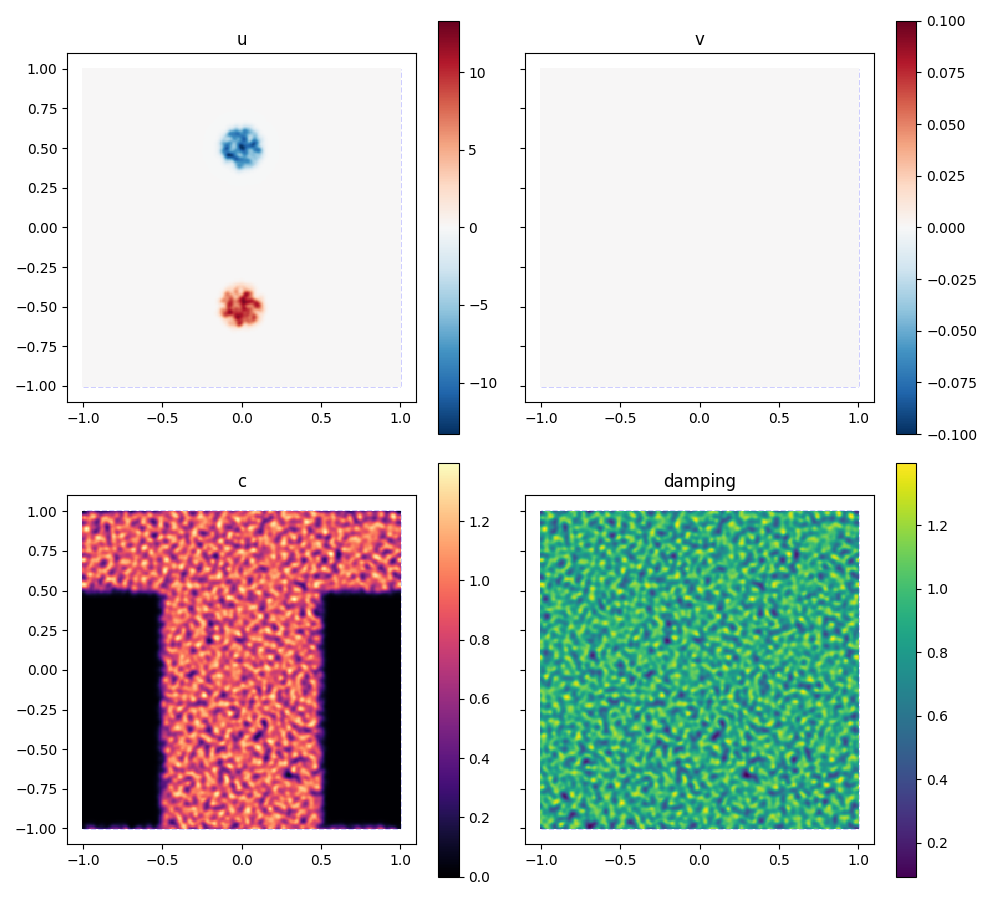

In [88]:

fig, axis, uPlot, vPlot, cPlot, dampPlot = plotState(
    particleState,
    smoothedState,
    markerSize = 0.5,
    plotGrid = True,
    plotCD = True)


In [91]:
imagePath = f'output/images/waveEqn_{getCurrentTimestamp()}'
os.makedirs(imagePath, exist_ok=True)
fig.savefig(f'{imagePath}/waveEqn_0000.png', dpi = 200)

In [90]:
import numpy as np
if export:
    us = []
    vs = []

    dudts = []
    dvdts = []

for i in tqdm(range(nIter), leave = False):
    waveSystem, updates =  integrator.function(
        waveSystem,
        dt = dt,
        f = waveSystemFunction,
        verbose = False,
        config = config,
    )
    t += dt

    if export:
        dudt = []
        dvdt = []
        for j in range(len(updates)):
            dudt.append(updates[j].dudt.cpu().numpy())
            dvdt.append(updates[j].dvdt.cpu().numpy())
        dudt = np.stack([torch.tensor(d) for d in dudt], axis=0).T
        dvdt = np.stack([torch.tensor(d) for d in dvdt], axis=0).T

        us.append(waveSystem.waveState.u.view(-1,1).cpu().numpy())
        vs.append(waveSystem.waveState.v.view(-1,1).cpu().numpy())
        dudts.append(dudt)
        dvdts.append(dvdt)

    if i % plotInterval == 0 or i == nIter - 1:
        updatePlot(uPlot, particleState, waveSystem.waveState.u)
        updatePlot(vPlot, particleState, waveSystem.waveState.v)

        fig.canvas.draw()
        fig.canvas.flush_events()
        # if export:
        fig.savefig(f'{imagePath}/waveEqn_{i+1:04d}.png', dpi = 200)


  0%|          | 0/1000 [00:00<?, ?it/s]

In [98]:
import subprocess
import shlex
output = 'timestamp'
scale = 1280

command = '/usr/bin/ffmpeg -loglevel warning -hide_banner -y -framerate 50 -f image2 -pattern_type glob -i '+ imagePath + '/waveEqn_*.png -c:v libx264 -b:v 20M -r 50 ' + imagePath + '/output.mp4'
commandB = f'ffmpeg -loglevel warning -hide_banner -y -i {imagePath}/output.mp4 -vf "fps=50,scale={scale}:-1:flags=lanczos,palettegen" {imagePath}/palette.png'
commandC = f'ffmpeg -loglevel warning -hide_banner -y -i {imagePath}/output.mp4 -i {imagePath}/palette.png -filter_complex "fps=50,scale={scale}:-1:flags=lanczos[x];[x][1:v]paletteuse" {imagePath}/output.gif'

print('Creating video from  frames (frame count: {})'.format(len(os.listdir(imagePath))))
subprocess.run(shlex.split(command))
print('Creating gif palette')
subprocess.run(shlex.split(commandB))
print('Creating gif')
subprocess.run(shlex.split(commandC))
print('Done')


Creating video from  frames (frame count: 102)
Creating gif palette
Creating gif
Done


In [ ]:
if export:        
    dudt_stacked = np.stack(dudts, axis=0)
    dvdt_stacked = np.stack(dvdts, axis=0)
    u_stacked = np.stack(us, axis=0)
    v_stacked = np.stack(vs, axis=0)

    simulationGroup.create_dataset('u', data = u_stacked)
    simulationGroup.create_dataset('v', data = v_stacked)
    simulationGroup.create_dataset('dudt', data = dudt_stacked)
    simulationGroup.create_dataset('dvdt', data = dvdt_stacked)

    outFile.close()

(1000, 16384, 4)
(1000, 16384, 1) (1000, 16384, 1)


<HDF5 dataset "dvdt": shape (1000, 16384, 4), type "<f4">

In [22]:
from ml import *
from diffSPH.sphOperations.shared import scatter_sum

class ScatterSumLayer(nn.Module):
    def __init__(self):
        super(ScatterSumLayer, self).__init__()
    def forward(self, input, index, dim, dim_size):
        return scatter_sum(input, index, dim=dim, dim_size=dim_size)
    
def runMLP_(mlp : torch.nn.Module, features : torch.Tensor, batches : int, verbose : bool = False):  
    if verbose:
        print(f'MLP {features.shape} -> {mlp[-1].out_features} features')
    transposedFeatures = features.view(batches,-1, *features.shape[1:])
    
    processedFeatures = mlp(transposedFeatures)
    processedFeatures = processedFeatures.view(-1, *processedFeatures.shape[2:])
    if verbose:
        print(f'\tFeatures: {processedFeatures.shape} [min: {torch.min(processedFeatures)}, max: {torch.max(processedFeatures)}, mean: {torch.mean(processedFeatures)}]')
    return processedFeatures
class SimpleGNN(torch.nn.Module):
    def __init__(self, hyperParameterDict):
        super(SimpleGNN, self).__init__()
            
        nodeFeatures = 3+ hyperParameterDict['featureCount']

        self.edgeMLP1 = buildMLPwDict({
            'layout': [hyperParameterDict['hiddenUnits']] * hyperParameterDict['hiddenLayers'],
            'inputFeatures': nodeFeatures*2 + hyperParameterDict['coordinateFeatures'],
            'output': hyperParameterDict['nodeFeatures'],
            'preNorm': False,
            'norm': False,
            # 'channels': [1],
            'activation': hyperParameterDict['activation'],
            'gain': hyperParameterDict['gain'],
        })
        self.activationLayer = getActivationLayer(hyperParameterDict['activation'])
        self.ScatterSumLayer = ScatterSumLayer()

        numFeatures = nodeFeatures*2 + hyperParameterDict['coordinateFeatures'] + hyperParameterDict['nodeFeatures']*2

        messagePassingVertexLayers = []
        messagePassingEdgeLayers = []
        for layer in range(hyperParameterDict['messagePassingLayers']):
            vertexMLP = buildMLPwDict({
                'layout': [hyperParameterDict['hiddenUnits']] * hyperParameterDict['hiddenLayers'],
                'inputFeatures': hyperParameterDict['nodeFeatures'],
                'output': hyperParameterDict['nodeFeatures'],
                'preNorm': False,
                'norm': False,
                # 'channels': [1],
                'activation': hyperParameterDict['activation'],
                'gain': 1,
            })
            edgeMLP = buildMLPwDict({
                'layout': [hyperParameterDict['hiddenUnits']] * hyperParameterDict['hiddenLayers'],
                'inputFeatures': numFeatures,
                'output': hyperParameterDict['output'] if layer == hyperParameterDict['messagePassingLayers'] - 1 and not hyperParameterDict['finalVertexMLP'] else hyperParameterDict['nodeFeatures'],
                'preNorm': False,
                'norm': False,
                'activation': hyperParameterDict['activation'],
                'gain': hyperParameterDict['gain'],
            })
            messagePassingVertexLayers.append(vertexMLP)
            messagePassingEdgeLayers.append(edgeMLP)

        self.messagePassingVertexLayers = torch.nn.ModuleList(messagePassingVertexLayers)
        self.messagePassingEdgeLayers = torch.nn.ModuleList(messagePassingEdgeLayers)
        self.hyperParameterDict = hyperParameterDict

        if hyperParameterDict['finalVertexMLP'] == True:
            self.finalVertexMLP = buildMLPwDict({
                'layout': [hyperParameterDict['hiddenUnits']] * hyperParameterDict['hiddenLayers'],
                'inputFeatures': hyperParameterDict['nodeFeatures'],
                'output': hyperParameterDict['output'],
                'preNorm': False,
                'norm': False,
                # 'channels': [1],
                'activation': hyperParameterDict['activation'],
                'gain': 1,
            })
        else:
            self.finalVertexMLP = None

    def forward(self, particles, neighbors, quantity):
        i, j = neighbors.get('noghost')[0].row, neighbors.get('noghost')[0].col
        hij = (particles.supports[i] + particles.supports[j]) / 2
        encodedDistances = basisEncoderLayer(
            neighbors.get('noghost')[1].x_ij/ hij.view(-1, 1),
            self.hyperParameterDict['basisTerms'], 
            self.hyperParameterDict['basis'],
            self.hyperParameterDict['encoderMode']
        )

        node_features = torch.cat([
            particles.supports.view(-1,1),
            particles.masses.view(-1,1),
            particles.densities.view(-1,1),
            quantity,]
        , dim = -1)

        edge_features = torch.cat([
            encodedDistances ,
            node_features[i],
            node_features[j]
        ], dim = -1)

        processedEdges = runMLP_(self.edgeMLP1, edge_features,1, verbose = False) * (particles.masses[j] / particles.densities[j]).view(-1, 1)

        aggregatedEdges = scatter_sum(processedEdges, i, dim = 0, dim_size = particles.positions.shape[0])
        for layer in range(self.hyperParameterDict['messagePassingLayers']):
            vertexFeatures = runMLP_(self.messagePassingVertexLayers[layer], aggregatedEdges, 1, verbose = False)
            vertexFeatures = self.activationLayer(vertexFeatures)

            newFeatures = torch.cat([
                vertexFeatures,
                particles.masses.view(-1, 1),
                particles.supports.view(-1, 1),
                particles.densities.view(-1,1),
                quantity,
            ], dim = -1)
            v_j = newFeatures[j]
            v_i = newFeatures[i]

            v_ij = torch.cat([v_i, v_j, encodedDistances / hij.view(-1, 1)], dim = -1)

            processedEdges = runMLP_(self.messagePassingEdgeLayers[layer], v_ij, 1, verbose = False) * (particles.masses[j] / particles.densities[j]).view(-1, 1)
            aggregatedEdges = scatter_sum(processedEdges, i, dim = 0, dim_size = particles.positions.shape[0])

        if self.finalVertexMLP is not None:
            vertexFeatures = runMLP_(self.finalVertexMLP, aggregatedEdges, 1, verbose = False)
            # vertexFeatures = self.activationLayer(vertexFeatures)
        else:
            vertexFeatures = aggregatedEdges
            
        return vertexFeatures
        # return scatter_sum(term, i, dim = 0, dim_size = particles.positions.shape[0])[:,0]


basisTerms = 4
hiddenLayers = 2
hiddenUnits = 64
nodeFeatures = 8
activation = 'gelu'

additionalEdgeFeatures = 6 # v_i, v_j, h_i, h_j

neighbors.get('noghost')[1].x_ij

encodedDistances = basisEncoderLayer(
    neighbors.get('noghost')[1].x_ij,
    basisTerms, 
    'ffourier',
    'cat'
)
GNN = SimpleGNN({
    'hiddenLayers': hiddenLayers,
    'hiddenUnits': hiddenUnits,
    'featureCount': additionalEdgeFeatures,
    'coordinateFeatures': encodedDistances.shape[1],
    'nodeFeatures': nodeFeatures,
    'output': 2,
    'activation': activation,
    'basisTerms': basisTerms,
    'basis': 'ffourier',
    'encoderMode': 'cat',
    'gain': 1/100,
    'messagePassingLayers': 2,
    'finalVertexMLP': True,
}).to(device)


optimizer = torch.optim.Adam(GNN.parameters(), lr=1e-2)
learningRateScheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=250, gamma=0.75)


In [23]:
system_rk4, update_rk4 = integrator_rk4.function(
    waveSystem,
    dt = dt,
    f = waveSystemFunction,
    verbose = False,
    config = config,
)
system_explicitEuler, update_explicitEuler = integrator_explicitEuler.function(
    waveSystem,
    dt = dt,
    f = waveSystemFunction,
    verbose = False,
    config = config,
)

In [26]:
for i in (t:= tqdm(range(1000), leave = False)):
    optimizer.zero_grad()
    system_gnn = waveSystem.initializeNewState()
    features = torch.cat([
        waveSystem.waveState.u.view(-1, 1),
        waveSystem.waveState.v.view(-1, 1),
        waveSystem.waveState.c.view(-1, 1),
        waveSystem.waveState.damping.view(-1, 1),
        update_explicitEuler[-1].dudt.view(-1, 1),
        update_explicitEuler[-1].dvdt.view(-1, 1),
    ], dim = -1)

    fi_nn = GNN(waveSystem.systemState, neighbors, features)
    dudt = fi_nn[:,0]
    dvdt = fi_nn[:,1]
    system_gnn.waveState.u = system_gnn.waveState.u + dudt * dt
    system_gnn.waveState.v = system_gnn.waveState.v + dvdt * dt

    uLoss = torch.mean((system_gnn.waveState.u - system_rk4.waveState.u)**2)
    vLoss = torch.mean((system_gnn.waveState.v - system_rk4.waveState.v)**2)
    loss = uLoss + vLoss
    # print(f'Loss: {loss.item()}')
    loss.backward()
    optimizer.step()
    learningRateScheduler.step()

    t.set_postfix_str(f'Loss: {loss.item():.3g}, lr: {optimizer.param_groups[0]["lr"]:.2e}, uLoss: {uLoss.item():.3g}, vLoss: {vLoss.item():.3g}')

  0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 